# Test1: Phân loại hoa Iris bằng thuật toán RIPPER
### Môn: Machine Learning
#### Đề 3 - Nguyễn Phúc Minh Châu

---
Trong bài này, sinh viên sẽ xây dựng bộ phân loại dựa trên luật (Rule-based classifier) sử dụng **RIPPER** (Repeated Incremental Pruning to Produce Error Reduction).

**Mục tiêu:**
- Áp dụng thuật toán RIPPER để phân loại dữ liệu hoa Iris.
- Huấn luyện theo hướng **One-vs-Rest (OVR)** để xử lý bài toán đa lớp.
- Đánh giá hiệu năng mô hình bằng các chỉ số: độ chính xác, ma trận nhầm lẫn, báo cáo phân loại.
- Trực quan hóa kết quả dự đoán.


## 1. Import các packages cần thiết

In [2]:
# Cài đặt thư viện nếu chưa có
!pip install wittgenstein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.6/110.6 kB 4.5 MB/s eta 0:00:00


In [3]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import wittgenstein as lw  # thư viện triển khai RIPPER

## 2. Load dataset

In [4]:
# Tải dataset Iris từ sklearn
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Chuyển nhãn số thành tên loài hoa
y = y.map({i: name for i, name in enumerate(iris.target_names)})

df = pd.concat([X, y.rename('class')], axis=1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. In thông tin của dataset

Số lượng mẫu: 150
Số thuộc tính: 4
Các lớp: [np.str_('setosa') np.str_('versicolor') np.str_('virginica')]

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   class              150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


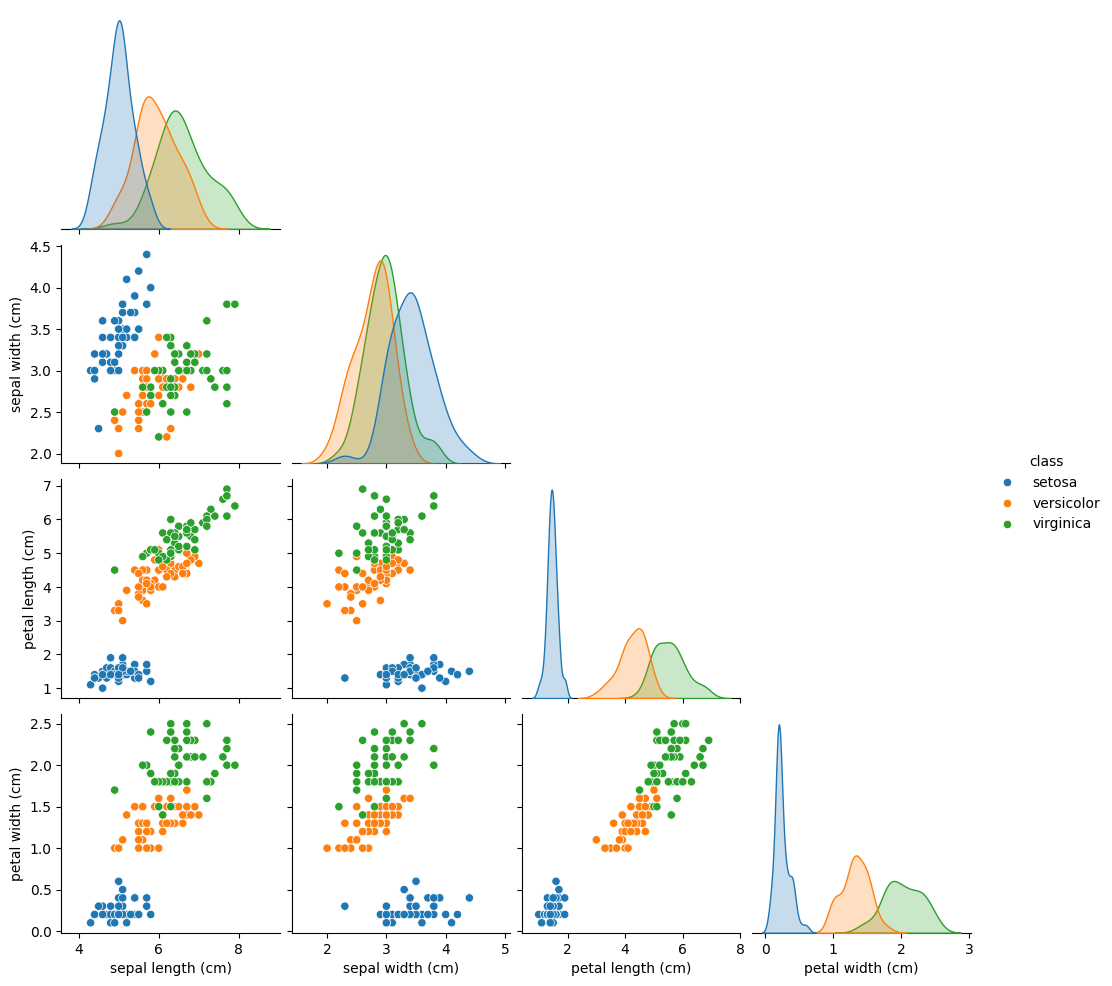

In [5]:
print("Số lượng mẫu:", df.shape[0])
print("Số thuộc tính:", df.shape[1]-1)
print("Các lớp:", df['class'].unique())
print("\nThông tin dữ liệu:")
print(df.info())

sns.pairplot(df, hue='class', corner=True)
plt.show()

## 4. Huấn luyện RIPPER theo One-vs-Rest (OVR)

In [11]:
# Chia dữ liệu huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Huấn luyện 1 mô hình RIPPER cho từng lớp (One-vs-Rest)
classes = y.unique()
models = {}

for cls in classes:
    y_binary = (y_train == cls).astype(int)  # lớp hiện tại là 1, lớp khác là 0
    y_binary.name = "class"  # Đặt tên cho cột nhãn (bắt buộc)

    # Ghép X_train và y_binary thành một DataFrame duy nhất
    train_df = X_train.copy()
    train_df["class"] = y_binary

    model = lw.RIPPER()
    model.fit(train_df, class_feat="class", pos_class=1)
    models[cls] = model
    print(f"Mô hình cho lớp '{cls}' được huấn luyện xong.")

Mô hình cho lớp 'setosa' được huấn luyện xong.
Mô hình cho lớp 'versicolor' được huấn luyện xong.
Mô hình cho lớp 'virginica' được huấn luyện xong.


## 5. Dự đoán bằng cách chọn class có độ tin cậy (confidence) cao nhất

In [12]:
# Tính độ tin cậy (probability) của mỗi mô hình đối với từng lớp
confidences = pd.DataFrame()
for cls, model in models.items():
    conf = model.predict_proba(X_test)[:, 1]  # xác suất thuộc lớp hiện tại
    confidences[cls] = conf

# Chọn lớp có độ tin cậy cao nhất
y_pred = confidences.idxmax(axis=1)
y_pred.head()

,0
0,virginica
1,versicolor
2,versicolor
3,virginica
4,virginica


## 6. Đánh giá mô hình (in độ chính xác)

In [13]:
acc = accuracy_score(y_test, y_pred)
print(f"Độ chính xác của mô hình: {acc:.4f}")

Độ chính xác của mô hình: 0.8667


## 7. Confusion Matrix

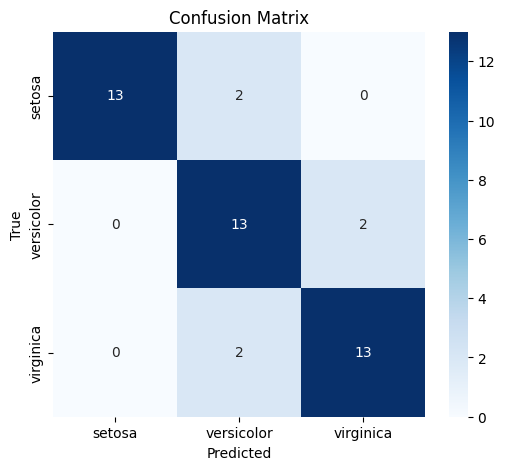

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

## 8. Classification Report

In [15]:
print('Báo cáo phân loại:')
print(classification_report(y_test, y_pred))

Báo cáo phân loại:
              precision    recall  f1-score   support

      setosa       1.00      0.87      0.93        15
  versicolor       0.76      0.87      0.81        15
   virginica       0.87      0.87      0.87        15

    accuracy                           0.87        45
   macro avg       0.88      0.87      0.87        45
weighted avg       0.88      0.87      0.87        45

